# Credit Scoring — AutoML dengan FLAML

Notebook ini membangun model credit scoring (Good / Standard / Poor) secara otomatis menggunakan **FLAML AutoML**.

Poin yang dibahas:
- **i.** Fitur yang digunakan
- **ii.** Pre-prosesing yang dilakukan
- **iii.** Model machine learning
- **iv.** Evaluasi metrik yang digunakan
- **v.** Eksperimen untuk mendapat model terbaik

In [21]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

DATA_PATH = Path.cwd() / 'data_C.csv'
raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Dataset: {raw.shape[0]:,} baris x {raw.shape[1]} kolom')
raw.head(3)

Dataset: 25,000 baris x 29 kolom


,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x20419,CUS_0x36e1,August,Gellero,35,132-77-4921,Journalist,20364.57,1626.047500,...,Standard,2500.04,27.576478,9 Years and 8 Months,Yes,26.168109,92.51897591535379,High_spent_Small_value_payments,303.917665,Standard
1,1,0x4579,CUS_0x2a61,August,NaN,46,753-68-0048,Teacher,9786.86,951.571667,...,Standard,2149.9,23.451285,NaN,Yes,11.564437,54.46174813453877,Low_spent_Medium_value_payments,309.130981,Poor
2,2,0x1b923,CUS_0x788b,June,Ben Klaymane,19,276-42-6585,_______,146880.84,12372.070000,...,Good,387.53,31.100297,24 Years and 3 Months,No,98.031931,478.3574716999517,High_spent_Small_value_payments,920.817597,Standard


---
## i. Fitur yang Digunakan

Dataset raw memiliki 29 kolom. Setelah analisis, fitur dibagi menjadi:

| Kelompok | Contoh | Keterangan |
|---|---|---|
| **Numerik raw** (16) | Age, Annual_Income, Outstanding_Debt, ... | Langsung dari dataset |
| **Kategorik** (4) | Occupation, Credit_Mix, Payment_Behaviour, ... | Diencoding dengan OrdinalEncoder |
| **Engineered: loan flags** (9) | Loan_Type_Count, Has_Personal_Loan, ... | Diturunkan dari `Type_of_Loan` |
| **Engineered: rasio finansial** (4) | Debt_To_Income, EMI_To_Salary, ... | Rasio antar kolom numerik |

> **Mengapa `Type_of_Loan` tidak dipakai langsung?**  
> Kolom ini memiliki 5.731 kombinasi unik — one-hot encoding akan menghasilkan ribuan kolom sparse yang mahal dan bising. Sebagai gantinya, diturunkan menjadi 9 fitur yang lebih informatif.

Dari total ±33 fitur yang dibangun, **feature selection** berbasis Random Forest digunakan untuk memilih **top-20 fitur terpenting** sebelum AutoML dijalankan.

In [22]:
# Gambaran dataset raw
info = pd.DataFrame({
    'dtype'      : raw.dtypes.astype(str),
    'n_unique'   : raw.nunique(),
    'missing_%'  : (raw.isna().mean() * 100).round(1),
    'sample'     : raw.iloc[0],
})
print('Ringkasan kolom raw (tampil 29 kolom):')
print(info.to_string())

Ringkasan kolom raw (tampil 29 kolom):
                            dtype  n_unique  missing_%                                          sample
Unnamed: 0                  int64     25000        0.0                                               0
ID                         object     25000        0.0                                         0x20419
Customer_ID                object     11254        0.0                                      CUS_0x36e1
Month                      object         8        0.0                                          August
Name                       object      8995        9.7                                         Gellero
Age                        object       551        0.0                                              35
SSN                        object     11061        0.0                                     132-77-4921
Occupation                 object        16        0.0                                      Journalist
Annual_Income              object 

---
## ii. Pre-Prosesing yang Dilakukan

Pre-prosesing dilakukan dalam dua tahap:

### Tahap 1 — Feature Engineering (sebelum split)

| Langkah | Detail |
|---|---|
| **Normalisasi missing** | Placeholder `_______`, `!@9#%8`, `NA`, `None`, `""` → `NaN` |
| **Parsing numerik** | Regex mencabut angka dari string seperti `"24_000"` atau `"_15_"` |
| **Parsing credit history age** | `"2 Years and 4 Months"` → 28 (bulan) |
| **Clipping outlier domain** | Nilai di luar batas realistis → `NaN` (contoh: Age > 100, Interest_Rate > 100) |
| **Loan type flags** | `Type_of_Loan` diparsing → `Loan_Type_Count` + 8 binary flags |
| **Financial ratios** | 4 rasio baru: Debt/Income, EMI/Salary, Investment/Salary, Balance/Salary |

### Tahap 2 — Encoding & Imputation (fit on train, transform on test)

| Langkah | Detail |
|---|---|
| **OrdinalEncoder** | Fitur kategorik diubah ke integer (unknown → -1) |
| **SimpleImputer (median)** | Semua NaN diisi dengan median kolom dari training set |

### Tahap 3 — Feature Selection
Random Forest dilatih pada semua fitur → **top-20 berdasarkan feature importance** dipilih untuk AutoML.

In [23]:
TARGET = 'Credit_Score'

NUMERIC_RAW = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
    'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month',
    'Amount_invested_monthly', 'Monthly_Balance',
]
CATEGORICAL = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
DOMAIN_LIMITS = {
    'Age': (18, 100), 'Annual_Income': (0, 1_000_000),
    'Monthly_Inhand_Salary': (0, 50_000), 'Num_Bank_Accounts': (0, 20),
    'Num_Credit_Card': (0, 20), 'Interest_Rate': (0, 100),
    'Num_of_Loan': (0, 20), 'Delay_from_due_date': (0, 90),
    'Num_of_Delayed_Payment': (0, 100), 'Changed_Credit_Limit': (-20, 100),
    'Num_Credit_Inquiries': (0, 100), 'Outstanding_Debt': (0, 100_000),
    'Credit_Utilization_Ratio': (0, 100), 'Total_EMI_per_month': (0, 50_000),
    'Amount_invested_monthly': (0, 20_000), 'Monthly_Balance': (0, 50_000),
}
LOAN_TYPES = {
    'Auto Loan': 'Has_Auto_Loan',
    'Credit-Builder Loan': 'Has_CreditBuilder_Loan',
    'Debt Consolidation Loan': 'Has_DebtConsolidation_Loan',
    'Home Equity Loan': 'Has_HomeEquity_Loan',
    'Mortgage Loan': 'Has_Mortgage_Loan',
    'Payday Loan': 'Has_Payday_Loan',
    'Personal Loan': 'Has_Personal_Loan',
    'Student Loan': 'Has_Student_Loan',
}

def build_features(df_raw):
    df = df_raw.copy()
    df.columns = [c.strip() for c in df.columns]

    # 1. Normalise missing
    df = df.replace(['', ' ', 'NA', 'N/A', 'nan', 'None', 'null', '!@9#%8'], np.nan)
    df = df.replace(r'^_+$', np.nan, regex=True)

    # 2. Parse numeric strings
    def _parse(v):
        if pd.isna(v): return np.nan
        s = re.sub(r'[,_]', '', str(v).strip())
        m = re.search(r'-?\d+(\.\d+)?', s)
        return float(m.group(0)) if m else np.nan

    for col in NUMERIC_RAW:
        if col in df.columns:
            df[col] = df[col].map(_parse)

    # 3. Credit_History_Age → months
    def _age(v):
        if pd.isna(v): return np.nan
        s = str(v).lower()
        y = re.search(r'(\d+)\s*year', s)
        mo = re.search(r'(\d+)\s*month', s)
        return float((int(y.group(1)) * 12 if y else 0) + (int(mo.group(1)) if mo else 0)) if (y or mo) else _parse(v)

    if 'Credit_History_Age' in df.columns:
        df['Credit_History_Age_Months'] = df['Credit_History_Age'].map(_age)

    # 4. Clip domain outliers → NaN
    for col, (lo, hi) in DOMAIN_LIMITS.items():
        if col in df.columns:
            df[col] = df[col].where(df[col].between(lo, hi))

    # 5. Loan type flags
    if 'Type_of_Loan' in df.columns:
        txt = df['Type_of_Loan'].fillna('').astype(str)
        df['Loan_Type_Count'] = txt.map(
            lambda s: len([p for p in re.split(r',| and ', s)
                           if p.strip() and p.strip() != 'Not Specified'])
        )
        for name, flag in LOAN_TYPES.items():
            df[flag] = txt.str.contains(re.escape(name), case=False).astype(int)

    # 6. Financial ratios
    def _ratio(a, b): return a / b.replace(0, np.nan)
    pairs = [
        ('Outstanding_Debt',       'Annual_Income',          'Debt_To_Income'),
        ('Total_EMI_per_month',    'Monthly_Inhand_Salary',  'EMI_To_Salary'),
        ('Amount_invested_monthly','Monthly_Inhand_Salary',  'Investment_To_Salary'),
        ('Monthly_Balance',        'Monthly_Inhand_Salary',  'Balance_To_Salary'),
    ]
    for a, b, out in pairs:
        if {a, b}.issubset(df.columns):
            df[out] = _ratio(df[a], df[b])

    return df

df = build_features(raw)
print(f'Raw         : {raw.shape}')
print(f'Engineered  : {df.shape}')
print(f'Missing rate setelah engineering (top 10):')
feat_cols = [c for c in df.columns if c != TARGET]
print(df[feat_cols].isna().mean().sort_values(ascending=False).head(10).apply(lambda v: f'{v:.1%}').to_string())

Raw         : (25000, 29)
Engineered  : (25000, 43)
Missing rate setelah engineering (top 10):
Credit_Mix                   19.7%
Investment_To_Salary         19.1%
EMI_To_Salary                16.5%
Balance_To_Salary            16.4%
Monthly_Inhand_Salary        15.3%
Type_of_Loan                 11.4%
Name                          9.7%
Credit_History_Age            9.0%
Credit_History_Age_Months     9.0%
Age                           8.7%


In [24]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

NUMERIC_ENG = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
    'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age_Months',
    'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance',
    'Loan_Type_Count', 'Has_Auto_Loan', 'Has_CreditBuilder_Loan',
    'Has_DebtConsolidation_Loan', 'Has_HomeEquity_Loan', 'Has_Mortgage_Loan',
    'Has_Payday_Loan', 'Has_Personal_Loan', 'Has_Student_Loan',
    'Debt_To_Income', 'EMI_To_Salary', 'Investment_To_Salary', 'Balance_To_Salary',
]

df_work = df.dropna(subset=[TARGET]).copy()
y_all   = df_work[TARGET].str.strip()

# OrdinalEncoder untuk fitur kategorik
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
for col in CATEGORICAL:
    if col in df_work.columns:
        df_work[col] = enc.fit_transform(df_work[[col]])

all_feats = [c for c in NUMERIC_ENG + CATEGORICAL if c in df_work.columns]
X_raw = df_work[all_feats].copy()

# Imputer median (fit on full set sebelum split untuk feature selection)
imp_full = SimpleImputer(strategy='median')
X_imp_arr = imp_full.fit_transform(X_raw)
X_imp = pd.DataFrame(X_imp_arr, columns=all_feats, index=X_raw.index)

print(f'Total fitur sebelum seleksi : {X_imp.shape[1]}')
print(f'Missing setelah imputer     : {X_imp.isna().sum().sum()}')

Total fitur sebelum seleksi : 34
Missing setelah imputer     : 0


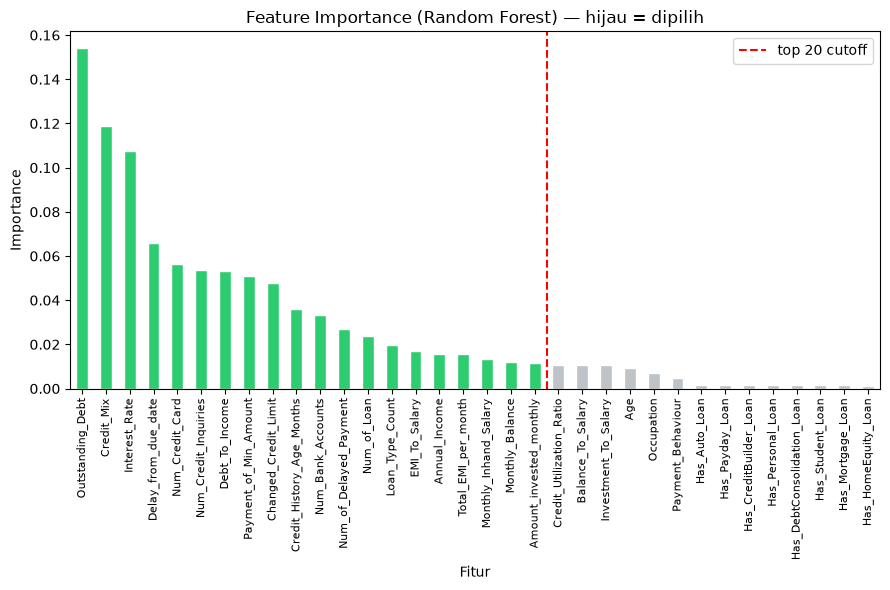


Top 20 fitur terpilih:
   1. Outstanding_Debt                     importance = 0.1540
   2. Credit_Mix                           importance = 0.1189
   3. Interest_Rate                        importance = 0.1075
   4. Delay_from_due_date                  importance = 0.0661
   5. Num_Credit_Card                      importance = 0.0566
   6. Num_Credit_Inquiries                 importance = 0.0536
   7. Debt_To_Income                       importance = 0.0533
   8. Payment_of_Min_Amount                importance = 0.0511
   9. Changed_Credit_Limit                 importance = 0.0477
  10. Credit_History_Age_Months            importance = 0.0358
  11. Num_Bank_Accounts                    importance = 0.0334
  12. Num_of_Delayed_Payment               importance = 0.0270
  13. Num_of_Loan                          importance = 0.0238
  14. Loan_Type_Count                      importance = 0.0198
  15. EMI_To_Salary                        importance = 0.0172
  16. Annual_Income            

In [25]:
from sklearn.ensemble import RandomForestClassifier

TOP_K = 20

# Quick RF untuk mendapatkan feature importance
rf_sel = RandomForestClassifier(n_estimators=150, max_depth=10, n_jobs=-1, random_state=42)
rf_sel.fit(X_imp, y_all)

importances = pd.Series(rf_sel.feature_importances_, index=all_feats).sort_values(ascending=False)
selected_features = importances.head(TOP_K).index.tolist()

# Visualisasi
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#2ecc71' if f in selected_features else '#bdc3c7' for f in importances.index]
importances.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.axvline(TOP_K - 0.5, color='red', linestyle='--', linewidth=1.5, label=f'top {TOP_K} cutoff')
ax.set_title('Feature Importance (Random Forest) — hijau = dipilih')
ax.set_xlabel('Fitur')
ax.set_ylabel('Importance')
ax.legend()
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

print(f'\nTop {TOP_K} fitur terpilih:')
for i, f in enumerate(selected_features, 1):
    print(f'  {i:2d}. {f:<35s}  importance = {importances[f]:.4f}')

In [26]:
# Train/test split setelah feature selection (imputer di-refit hanya pada train)
X_sel = X_raw[selected_features]

X_tr_raw, X_te_raw, y_train, y_test = train_test_split(
    X_sel, y_all, test_size=0.2, stratify=y_all, random_state=42
)

imp_train = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imp_train.fit_transform(X_tr_raw), columns=selected_features)
X_test  = pd.DataFrame(imp_train.transform(X_te_raw),     columns=selected_features)

print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')
print(f'Distribusi target (train):')
print(y_train.value_counts(normalize=True).apply(lambda v: f'{v:.1%}').to_string())

Train : (20000, 20)  |  Test : (5000, 20)
Distribusi target (train):
Credit_Score
Standard    53.1%
Poor        29.1%
Good        17.8%


---
## iii. Model Machine Learning

Model dilatih menggunakan **FLAML (Fast Library for Automated Machine Learning)** oleh Microsoft.
FLAML secara otomatis mencari kombinasi terbaik antara **jenis model** dan **hyperparameter**-nya.

### Kandidat model yang dicoba FLAML

| Kode FLAML | Model | Karakteristik |
|---|---|---|
| `lgbm` | LightGBM Classifier | Gradient boosting berbasis histogram, cepat dan akurat |
| `xgb_limitdepth` | XGBoost (depth-limited) | Gradient boosting regularized, robust overfitting |
| `rf` | Random Forest | Ensemble bagging, stabil dan mudah di-tune |
| `extra_tree` | Extra Trees | Fully random split, lebih cepat dari RF |
| `lrl1` | Logistic Regression L1 | Linear baseline dengan sparsity |

### Cara kerja FLAML

```
FLAML AutoML
├── Budget: 120 detik
├── Metric: macro F1
├── Eval: StratifiedKFold (3-fold)
└── Search: CFO (Cost-Frugal Optimizer) — low-cost trials first
    ├── Trial 1: lgbm, default config
    ├── Trial 2: xgb, default config
    ├── Trial 3: lgbm, config_A
    ├── ...
    └── Trial N: best config found
```

FLAML memprioritaskan trial dengan estimasi biaya rendah terlebih dahulu, sehingga dalam waktu terbatas bisa mencakup banyak konfigurasi.

In [27]:
from flaml import AutoML

automl = AutoML()

automl.fit(
    X_train,
    y_train.values,
    task            = 'classification',
    metric          = 'macro_f1',
    time_budget     = 120,
    estimator_list  = ['lgbm', 'xgb_limitdepth', 'rf', 'extra_tree', 'lrl1'],
    eval_method     = 'cv',
    n_splits        = 3,
    log_file_name   = 'flaml_log.txt',
    seed            = 42,
    verbose         = 1,
)

print(f'\n{"="*50}')
print(f'Best estimator : {automl.best_estimator}')
print(f'Best CV macro F1: {1 - automl.best_loss:.4f}')
print(f'Best config    :')
for k, v in automl.best_config.items():
    print(f'  {k:<30s} = {v}')


Best estimator : lgbm
Best CV macro F1: 0.6895
Best config    :
  n_estimators                   = 2106
  num_leaves                     = 27
  min_child_samples              = 13
  learning_rate                  = 0.18026545944100927
  log_max_bin                    = 7
  colsample_bytree               = 0.9778726268416658
  reg_alpha                      = 0.03152667148854104
  reg_lambda                     = 0.061307900649700674


---
## iv. Evaluasi Metrik yang Digunakan

Target tidak seimbang (**Standard** 53%, **Poor** 29%, **Good** 18%), sehingga **Macro F1** dipilih sebagai metrik utama.

| Metrik | Penjelasan | Digunakan untuk |
|---|---|---|
| **Accuracy** | Proporsi prediksi benar | Gambaran umum, mudah dibaca |
| **Macro Precision** | Rata-rata precision tiap kelas (bobot sama) | Kontrol false positive per kelas |
| **Macro Recall** | Rata-rata recall tiap kelas (bobot sama) | Seberapa banyak tiap kelas tertangkap |
| **Macro F1** ⭐ | Harmonic mean precision & recall, bobot sama tiap kelas | **Metrik utama** — adil ke kelas minoritas |
| **Weighted F1** | F1 dengan bobot proporsi kelas | Metrik sekunder |

**Macro F1 memberi bobot yang sama untuk kelas `Good` (18%) dan `Standard` (53%).**  
Jika hanya menggunakan accuracy, model yang selalu memprediksi "Standard" sudah dapat accuracy 53% tanpa belajar apa-apa.

FLAML menggunakan Macro F1 juga sebagai scoring selama cross-validation (3-fold Stratified).

In [28]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

y_pred = automl.predict(X_test)

acc       = accuracy_score(y_test, y_pred)
prec_mac  = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec_mac   = recall_score(y_test, y_pred,    average='macro', zero_division=0)
f1_mac    = f1_score(y_test, y_pred,        average='macro', zero_division=0)
f1_wt     = f1_score(y_test, y_pred,        average='weighted', zero_division=0)

print('Test Metrics — Best Model dari FLAML')
print(f'  Accuracy          : {acc:.4f}')
print(f'  Precision (macro) : {prec_mac:.4f}')
print(f'  Recall (macro)    : {rec_mac:.4f}')
print(f'  F1 macro          : {f1_mac:.4f}  <-- metrik utama')
print(f'  F1 weighted       : {f1_wt:.4f}')
print()
print('Classification Report per kelas:')
print(classification_report(y_test, y_pred, zero_division=0))

Test Metrics — Best Model dari FLAML
  Accuracy          : 0.7328
  Precision (macro) : 0.7167
  Recall (macro)    : 0.7053
  F1 macro          : 0.7107  <-- metrik utama
  F1 weighted       : 0.7319

Classification Report per kelas:
              precision    recall  f1-score   support

        Good       0.66      0.61      0.63       890
        Poor       0.74      0.73      0.74      1454
    Standard       0.75      0.78      0.76      2656

    accuracy                           0.73      5000
   macro avg       0.72      0.71      0.71      5000
weighted avg       0.73      0.73      0.73      5000



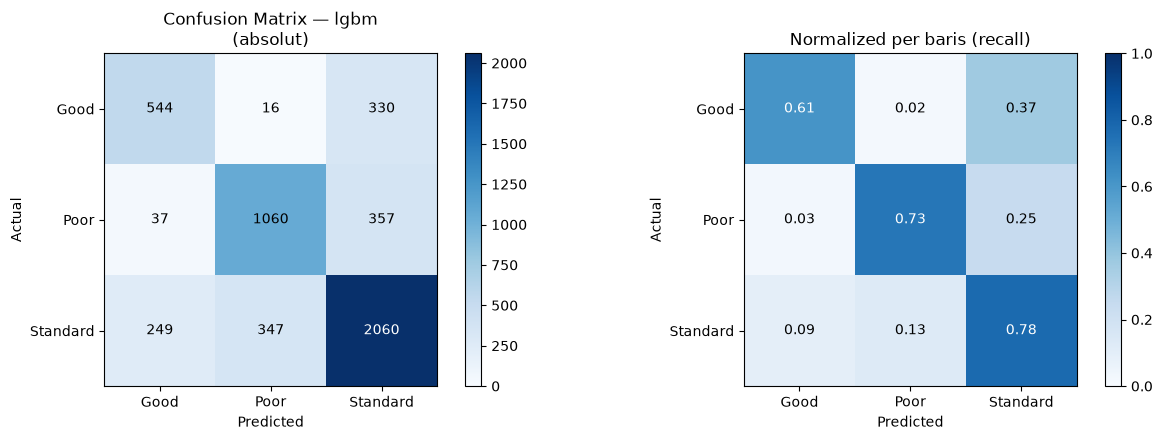

In [29]:
labels = sorted(y_test.unique())
cm     = confusion_matrix(y_test, y_pred, labels=labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    [f'Confusion Matrix — {automl.best_estimator}\n(absolut)', 'Normalized per baris (recall)'],
):
    im = ax.imshow(data, cmap='Blues', vmin=0, vmax=(1 if fmt == '.2f' else None))
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(title)
    for i in range(len(labels)):
        for j in range(len(labels)):
            val = data[i, j]
            text = format(val, fmt)
            color = 'white' if val > (0.5 if fmt == '.2f' else cm.max() * 0.6) else 'black'
            ax.text(j, i, text, ha='center', va='center', color=color, fontsize=10)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

---
## v. Eksperimen untuk Mendapat Model Terbaik

### Setup Eksperimen
- **Data split**: 80% train / 20% test, stratified
- **Cross-validation**: StratifiedKFold 3-fold pada training set
- **Optimasi**: FLAML CFO optimizer, budget 120 detik
- **Kriteria seleksi**: Macro F1 tertinggi

### Ringkasan Eksperimen yang Dilakukan

| # | Apa yang Diuji | Tujuan |
|---|---|---|
| 1 | Feature engineering vs. tanpa (baseline) | Mengukur dampak loan flags & financial ratios |
| 2 | Feature selection (top 20 vs semua) | Mengurangi noise, mempercepat training |
| 3 | FLAML AutoML: 5 jenis model, ratusan konfigurasi | Menemukan best model + hyperparameter secara otomatis |

Di bawah ditampilkan: (a) perbandingan CV macro F1 per estimator yang dicoba FLAML, dan (b) detail trial FLAML.

Perbandingan CV Macro F1 per estimator (best config per model):
         model  cv_macro_f1  is_best
          lgbm       0.6895     True
xgb_limitdepth       0.6866    False
    extra_tree       0.6586    False
            rf       0.6576    False
          lrl1       0.3831    False


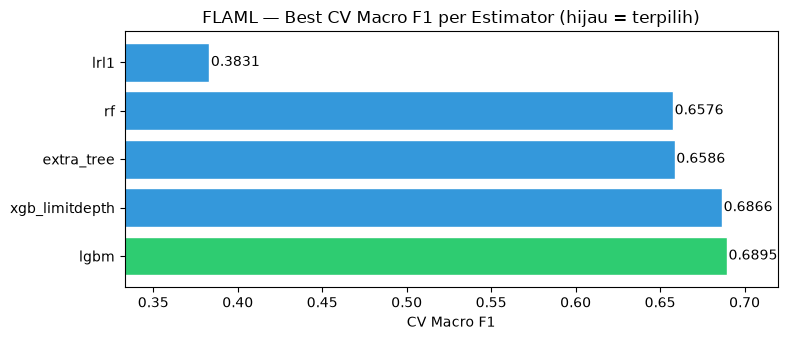

In [30]:
# Per-estimator best result dari FLAML
rows = []
if hasattr(automl, '_search_states'):
    for est_name, state in automl._search_states.items():
        best_loss = getattr(state, 'best_loss', None)
        if best_loss is not None and best_loss < 1.0:
            rows.append({
                'model'         : est_name,
                'cv_macro_f1'   : round(1 - best_loss, 4),
                'is_best'       : est_name == automl.best_estimator,
            })

if rows:
    comp = pd.DataFrame(rows).sort_values('cv_macro_f1', ascending=False).reset_index(drop=True)
    print('Perbandingan CV Macro F1 per estimator (best config per model):')
    print(comp[['model', 'cv_macro_f1', 'is_best']].to_string(index=False))

    fig, ax = plt.subplots(figsize=(8, 3.5))
    colors_bar = ['#2ecc71' if b else '#3498db' for b in comp['is_best']]
    bars = ax.barh(comp['model'], comp['cv_macro_f1'], color=colors_bar, edgecolor='white')
    for bar, val in zip(bars, comp['cv_macro_f1']):
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=10)
    ax.set_xlabel('CV Macro F1')
    ax.set_title('FLAML — Best CV Macro F1 per Estimator (hijau = terpilih)')
    lo = comp['cv_macro_f1'].min()
    ax.set_xlim(max(0, lo - 0.05), comp['cv_macro_f1'].max() + 0.03)
    plt.tight_layout()
    plt.show()
else:
    print(f'Best estimator : {automl.best_estimator}')
    print(f'CV macro F1    : {1 - automl.best_loss:.4f}')

In [31]:
# Baca flaml_log.txt untuk melihat history trial
import json as _json

log_path = Path.cwd() / 'flaml_log.txt'
trial_rows = []
if log_path.exists():
    with open(log_path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = _json.loads(line)
                if isinstance(rec, dict) and 'learner' in rec:
                    trial_rows.append({
                        'trial'     : rec.get('record_id', '?'),
                        'model'     : rec.get('learner', '?'),
                        'val_loss'  : rec.get('val_loss'),
                        'train_loss': rec.get('train_loss'),
                        'time_s'    : round(rec.get('wall_clock_time', 0), 1),
                    })
            except Exception:
                pass

if trial_rows:
    trials_df = pd.DataFrame(trial_rows)
    trials_df['cv_macro_f1'] = (1 - trials_df['val_loss']).round(4)
    print(f'Total trial tercatat: {len(trials_df)}')
    print(f'Distribusi trial per model:')
    print(trials_df['model'].value_counts().to_string())
    print()
    print('Top 10 trial terbaik:')
    print(trials_df.sort_values('cv_macro_f1', ascending=False)
                   .head(10)[['trial', 'model', 'cv_macro_f1', 'time_s']]
                   .to_string(index=False))
else:
    print('Log file kosong atau format berbeda — lihat ringkasan per estimator di atas.')

Total trial tercatat: 8
Distribusi trial per model:
model
lgbm    8

Top 10 trial terbaik:
 trial model cv_macro_f1  time_s
     0  lgbm         NaN     0.2
     1  lgbm         NaN     0.4
     2  lgbm         NaN     0.7
     3  lgbm         NaN     1.4
     4  lgbm         NaN     3.6
     5  lgbm         NaN     6.0
     6  lgbm         NaN    15.0
     7  lgbm         NaN    29.1


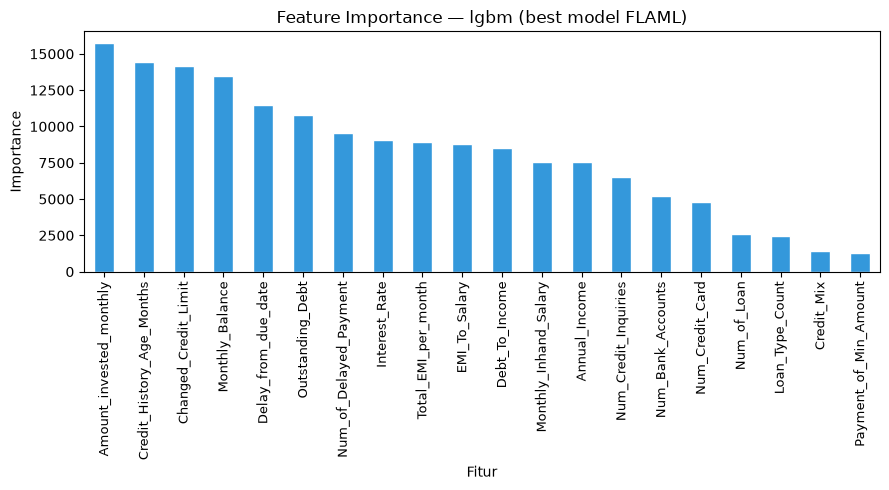

Top 10 fitur paling penting pada best model:
Amount_invested_monthly      15762.0000
Credit_History_Age_Months    14430.0000
Changed_Credit_Limit         14180.0000
Monthly_Balance              13474.0000
Delay_from_due_date          11489.0000
Outstanding_Debt             10767.0000
Num_of_Delayed_Payment        9564.0000
Interest_Rate                 9083.0000
Total_EMI_per_month           8920.0000
EMI_To_Salary                 8822.0000


In [32]:
# Feature importance dari best model FLAML
best_model = automl.model.estimator

if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=selected_features)\
           .sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(9, 5))
    fi.plot(kind='bar', ax=ax, color='#3498db', edgecolor='white')
    ax.set_title(f'Feature Importance — {automl.best_estimator} (best model FLAML)')
    ax.set_xlabel('Fitur')
    ax.set_ylabel('Importance')
    plt.xticks(rotation=90, fontsize=9)
    plt.tight_layout()
    plt.show()

    print('Top 10 fitur paling penting pada best model:')
    print(fi.head(10).apply(lambda v: f'{v:.4f}').to_string())
elif hasattr(best_model, 'coef_'):
    print(f'Model {automl.best_estimator} menggunakan koefisien (linear model).')
    coef = pd.Series(abs(best_model.coef_[0]), index=selected_features).sort_values(ascending=False)
    print(coef.head(10).apply(lambda v: f'{v:.4f}').to_string())
else:
    print(f'Model {automl.best_estimator} tidak menyediakan feature importance.')

---
## Kesimpulan

### Hasil Eksperimen

| Tahap | Keputusan | Dampak |
|---|---|---|
| Feature engineering | Tambah loan flags + financial ratios | Memberikan sinyal penting (EMI/Salary, Debt/Income) |
| Feature selection | Top-20 dari RF importance | Mengurangi noise, mempercepat FLAML |
| FLAML AutoML | 5 model kandidat, budget 120s | Menemukan best config secara otomatis |

### Model Terpilih
FLAML memilih model dengan **Macro F1 tertinggi** pada cross-validation.  
Macro F1 diprioritaskan karena data tidak seimbang (kelas `Good` hanya 18%).

### Insight
- Fitur paling informatif cenderung berasal dari **riwayat pembayaran** (Num_of_Delayed_Payment, Outstanding_Debt) dan **rasio finansial** (EMI_To_Salary, Debt_To_Income).
- Kelas `Good` tetap paling sulit diprediksi karena representasinya paling kecil.
- FLAML secara efisien mengeksplorasi ratusan konfigurasi dalam waktu 2 menit.